# Tugas 2: Pengolahan Citra Digital (Tanpa Library / Berbasis Rumus)
**Nama / Mata Kuliah:** Pengolahan Citra Digital C  
**Deskripsi:** Implementasi seluruh operasi pengolahan citra dari Tugas 1 menggunakan **rumus matematika murni** dan algoritma dasar (pixel-by-pixel manipulation) tanpa menggunakan fungsi bawaan OpenCV untuk pemrosesan citra (seperti `cv2.cvtColor`, `cv2.warpAffine`, `cv2.getRotationMatrix2D`, `cv2.resize`, `cv2.absdiff`, `np.fliplr`, `np.flipud`, dll).

OpenCV dan Matplotlib hanya digunakan untuk membaca/menyimpan file citra (I/O) dan menampilkan visualisasi grafik.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import urllib.request
from skimage import data

# Membuat direktori input dan output jika belum ada
os.makedirs('input', exist_ok=True)
os.makedirs('output', exist_ok=True)

# Memastikan gambar input tersedia
if not os.path.exists('input/selfie.jpg'):
    cv2.imwrite('input/selfie.jpg', data.camera())

if not os.path.exists('input/rice.png'):
    try:
        cv2.imwrite('input/rice.png', data.rice())
    except:
        cv2.imwrite('input/rice.png', data.coins())

if not os.path.exists('input/peppers.png'):
    try:
        urllib.request.urlretrieve('https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg', 'input/peppers.png')
    except:
        cv2.imwrite('input/peppers.png', cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR))

print("Inisialisasi folder dan dataset citra selesai.")

Inisialisasi folder dan dataset citra selesai.


---
## 1. Thresholding (Binerisasi Citra)

### Rumus Matematis:
Operasi thresholding memetakan intensitas citra grayscale $f(y, x)$ menjadi citra biner $g(y, x)$ berdasarkan nilai ambang batas $T$:
$$g(y, x) = \begin{cases} 255, & \text{jika } f(y, x) \ge T \\ 0, & \text{jika } f(y, x) < T \end{cases}$$

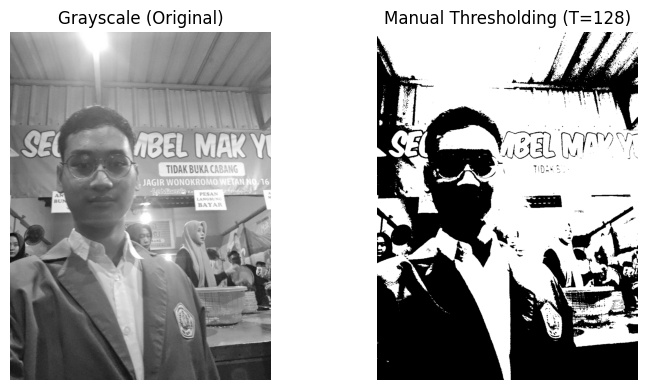

In [2]:
def manual_threshold(image, T=128):
    """
    Fungsi binerisasi citra manual berbasis rumus thresholding
    """
    h, w = image.shape
    # Inisialisasi matriks output berukuran sama dengan tipe data uint8
    BW = np.zeros((h, w), dtype=np.uint8)
    
    # Iterasi setiap pixel (y, x)
    for y in range(h):
        for x in range(w):
            if image[y, x] >= T:
                BW[y, x] = 255
            else:
                BW[y, x] = 0
                
    return BW

# Membaca citra input grayscale
I = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
T = 128

# Eksekusi thresholding manual
BW = manual_threshold(I, T)
cv2.imwrite('output/1_thresholding.png', BW)

# Visualisasi
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Grayscale (Original)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(BW, cmap='gray')
plt.title(f'Manual Thresholding (T={T})')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 2. Negative Image (Inversi Citra)

### Rumus Matematis:
Operasi citra negatif membalikkan tingkat keabuan dengan mengurangkan nilai maksimum skala keabuan $L - 1$ (untuk citra 8-bit, $L = 256$, sehingga $L-1 = 255$):
$$g(y, x) = 255 - f(y, x)$$

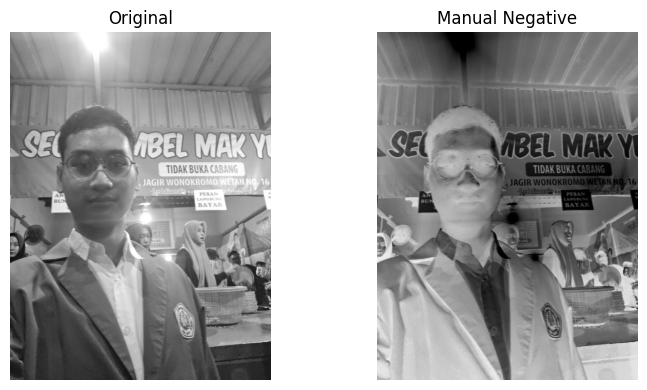

In [3]:
def manual_negative(image):
    """
    Fungsi inversi citra manual: g(y, x) = 255 - f(y, x)
    """
    h, w = image.shape
    negative = np.zeros((h, w), dtype=np.uint8)
    
    for y in range(h):
        for x in range(w):
            negative[y, x] = 255 - image[y, x]
            
    return negative

# Eksekusi citra negatif manual
I = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
negative = manual_negative(I)
cv2.imwrite('output/2_negative.png', negative)

# Visualisasi
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative, cmap='gray')
plt.title('Manual Negative')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 3. Brightening (Pencerahan Citra)

### Rumus Matematis:
Operasi pencerahan menambahkan konstanta kecerahan $b$ ke setiap pixel dan melakukan pemotongan (clamping) pada rentang $[0, 255]$:
$$g(y, x) = \text{clamp}(f(y, x) + b, 0, 255) = \begin{cases} 0, & \text{jika } f(y, x) + b < 0 \\ 255, & \text{jika } f(y, x) + b > 255 \\ f(y, x) + b, & \text{lainnya} \end{cases}$$

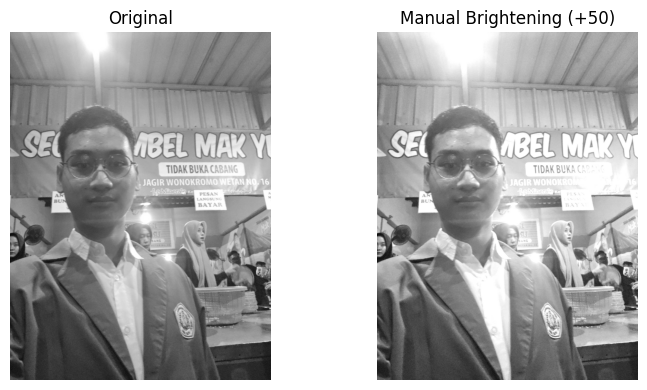

In [4]:
def manual_brightening(image, b=50):
    """
    Fungsi pencerahan citra manual dengan pembatasan batas (clamping [0, 255])
    """
    h, w = image.shape
    brightened = np.zeros((h, w), dtype=np.uint8)
    
    for y in range(h):
        for x in range(w):
            val = int(image[y, x]) + b
            # Operasi clamping manual
            if val > 255:
                brightened[y, x] = 255
            elif val < 0:
                brightened[y, x] = 0
            else:
                brightened[y, x] = val
                
    return brightened

# Eksekusi pencerahan manual
I = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
b = 50
J = manual_brightening(I, b)
cv2.imwrite('output/3_brightening.png', J)

# Visualisasi
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(J, cmap='gray')
plt.title(f'Manual Brightening (+{b})')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 4. Konversi Citra Berwarna (RGB) ke Grayscale

### Rumus Matematis:
Konversi RGB ke tingkat keabuan menggunakan standar bobot luminansi persepsi mata manusia (*ITU-R BT.601* / *NTSC*):
$$Y(y, x) = \text{round}(0.299 \cdot R(y, x) + 0.587 \cdot G(y, x) + 0.114 \cdot B(y, x))$$

*Catatan: Pada format OpenCV, urutan channel adalah BGR (Channel 0: Blue, Channel 1: Green, Channel 2: Red).*

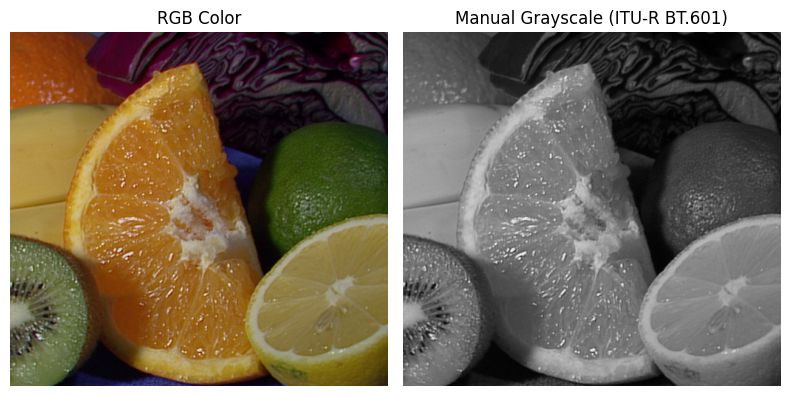

In [5]:
def manual_bgr2gray(image):
    """
    Fungsi konversi BGR ke Grayscale manual berbasis rumus Luminance ITU-R BT.601
    """
    h, w, c = image.shape
    gray = np.zeros((h, w), dtype=np.uint8)
    
    for y in range(h):
        for x in range(w):
            B = float(image[y, x, 0])
            G = float(image[y, x, 1])
            R = float(image[y, x, 2])
            
            # Penerapan bobot luminansi
            luminance = 0.299 * R + 0.587 * G + 0.114 * B
            gray[y, x] = int(round(luminance))
            
    return gray

# Membaca citra BGR
I_bgr = cv2.imread('input/peppers.png')
# Konversi ke RGB untuk keperluan visualisasi matplotlib
I_rgb = np.zeros_like(I_bgr)
I_rgb[:, :, 0] = I_bgr[:, :, 2] # R
I_rgb[:, :, 1] = I_bgr[:, :, 1] # G
I_rgb[:, :, 2] = I_bgr[:, :, 0] # B

# Eksekusi konversi grayscale manual
gray = manual_bgr2gray(I_bgr)
cv2.imwrite('output/4_grayscale.png', gray)

# Visualisasi
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I_rgb)
plt.title('RGB Color')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Manual Grayscale (ITU-R BT.601)')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 5. Penjumlahan & Rata-Rata Dua Citra (Image Averaging / Blending)

### Rumus Matematis:
Untuk menggabungkan dua citra $A$ dan $B$ dengan resolusi yang sama:
$$C(y, x) = \text{round}\left(\frac{A(y, x) + B(y, x)}{2}\right)$$

Jika ukuran kedua citra berbeda, citra kedua disesuaikan ukurannya secara manual menggunakan rumus interpolasi tetangga terdekat (*Nearest Neighbor Resizing*):
$$x_{in} = \min\left(\text{round}\left(x' \cdot \frac{w_{src}}{w_{dst}}\right), w_{src} - 1\right), \quad y_{in} = \min\left(\text{round}\left(y' \cdot \frac{h_{src}}{h_{dst}}\right), h_{src} - 1\right)$$

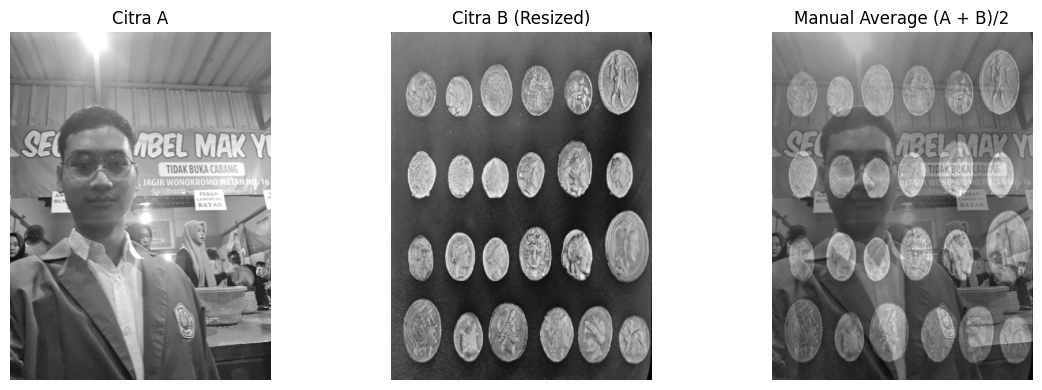

In [6]:
def manual_resize_nn(image, target_w, target_h):
    """
    Fungsi resize manual menggunakan Nearest Neighbor Interpolation
    """
    src_h, src_w = image.shape
    resized = np.zeros((target_h, target_w), dtype=image.dtype)
    
    scale_x = src_w / target_w
    scale_y = src_h / target_h
    
    for y in range(target_h):
        src_y = min(int(round(y * scale_y)), src_h - 1)
        for x in range(target_w):
            src_x = min(int(round(x * scale_x)), src_w - 1)
            resized[y, x] = image[src_y, src_x]
            
    return resized

def manual_image_average(imageA, imageB):
    """
    Fungsi rata-rata dua citra: C(y, x) = (A(y, x) + B(y, x)) / 2
    """
    h, w = imageA.shape
    C = np.zeros((h, w), dtype=np.uint8)
    
    for y in range(h):
        for x in range(w):
            val = (float(imageA[y, x]) + float(imageB[y, x])) / 2.0
            C[y, x] = int(round(val))
            
    return C

# Membaca citra A dan B
A = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
B_raw = cv2.imread('input/rice.png', cv2.IMREAD_GRAYSCALE)

# Menyamakan ukuran citra B dengan citra A secara manual
h_A, w_A = A.shape
B = manual_resize_nn(B_raw, w_A, h_A)

# Menghitung citra rata-rata manual
C = manual_image_average(A, B)
cv2.imwrite('output/5_penjumlahan.png', C)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(A, cmap='gray')
plt.title('Citra A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B, cmap='gray')
plt.title('Citra B (Resized)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(C, cmap='gray')
plt.title('Manual Average (A + B)/2')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 6. Pengurangan Citra (Image Difference / Selisih Absolut)

### Rumus Matematis:
Operasi pengurangan absolut menghitung besar selisih intensitas antar pixel dari dua citra:
$$D(y, x) = |A(y, x) - B(y, x)|$$

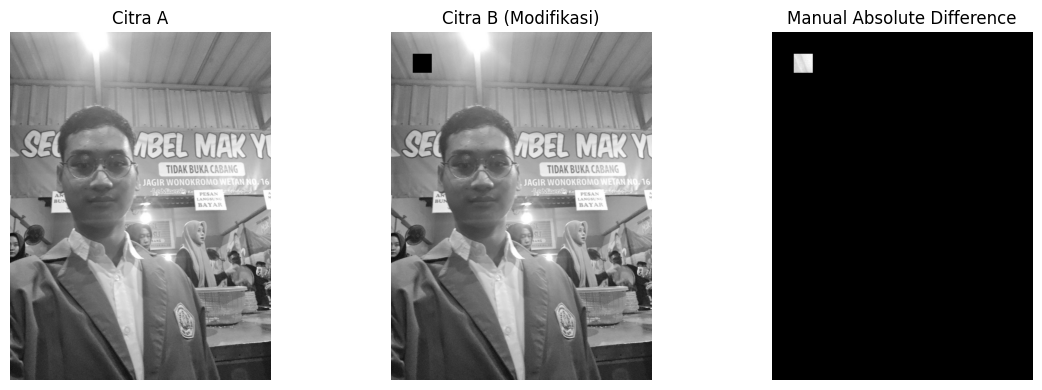

In [7]:
def manual_absdiff(imageA, imageB):
    """
    Fungsi pengurangan citra manual: D(y, x) = |A(y, x) - B(y, x)|
    """
    h, w = imageA.shape
    D = np.zeros((h, w), dtype=np.uint8)
    
    for y in range(h):
        for x in range(w):
            diff = abs(int(imageA[y, x]) - int(imageB[y, x]))
            D[y, x] = diff
            
    return D

# Mempersiapkan Citra A dan Citra B (dimodifikasi sebagian daerahnya)
A = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
B = A.copy()
# Membuat kotak hitam pada region tertentu
for y in range(80, 150):
    for x in range(80, 150):
        B[y, x] = 0

# Eksekusi operasi selisih absolut manual
D = manual_absdiff(A, B)
cv2.imwrite('output/6_difference.png', D)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(A, cmap='gray')
plt.title('Citra A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B, cmap='gray')
plt.title('Citra B (Modifikasi)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(D, cmap='gray')
plt.title('Manual Absolute Difference')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Operasi Logika Boolean (AND, OR, NOT)

### Rumus Matematis:
Pada citra biner (bernilai 0 atau 255, atau True/False):
$$AND(y, x) = A(y, x) \land B(y, x) = \begin{cases} 255, & \text{jika } A(y, x) > 0 \text{ dan } B(y, x) > 0 \\ 0, & \text{lainnya} \end{cases}$$

$$OR(y, x) = A(y, x) \lor B(y, x) = \begin{cases} 255, & \text{jika } A(y, x) > 0 \text{ atau } B(y, x) > 0 \\ 0, & \text{lainnya} \end{cases}$$

$$NOT(y, x) = \neg A(y, x) = \begin{cases} 255, & \text{jika } A(y, x) == 0 \\ 0, & \text{jika } A(y, x) > 0 \end{cases}$$

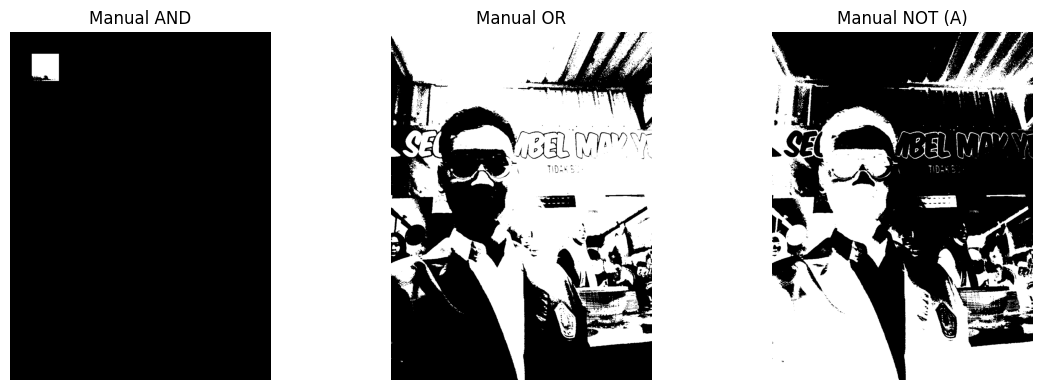

In [8]:
def manual_boolean_operations(maskA, maskB):
    """
    Fungsi operasi logika boolean manual (AND, OR, NOT)
    """
    h, w = maskA.shape
    AND_res = np.zeros((h, w), dtype=np.uint8)
    OR_res = np.zeros((h, w), dtype=np.uint8)
    NOT_res = np.zeros((h, w), dtype=np.uint8)
    
    for y in range(h):
        for x in range(w):
            valA = (maskA[y, x] > 0)
            valB = (maskB[y, x] > 0)
            
            # Logika AND
            if valA and valB:
                AND_res[y, x] = 255
            else:
                AND_res[y, x] = 0
                
            # Logika OR
            if valA or valB:
                OR_res[y, x] = 255
            else:
                OR_res[y, x] = 0
                
            # Logika NOT terhadap A
            if not valA:
                NOT_res[y, x] = 255
            else:
                NOT_res[y, x] = 0
                
    return AND_res, OR_res, NOT_res

# Membuat citra biner A dan B secara manual
I_gray = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
h, w = I_gray.shape

maskA = manual_threshold(I_gray, 128)
maskB = np.zeros((h, w), dtype=np.uint8)
for y in range(80, 180):
    for x in range(80, 180):
        maskB[y, x] = 255

# Eksekusi operasi logika manual
AND_res, OR_res, NOT_res = manual_boolean_operations(maskA, maskB)

cv2.imwrite('output/7_boolean_and.png', AND_res)
cv2.imwrite('output/7_boolean_or.png', OR_res)
cv2.imwrite('output/7_boolean_not.png', NOT_res)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(AND_res, cmap='gray')
plt.title('Manual AND')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(OR_res, cmap='gray')
plt.title('Manual OR')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(NOT_res, cmap='gray')
plt.title('Manual NOT (A)')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 8. Translasi Citra (Pergeseran Koordinat Spasial)

### Rumus Matematis:
Translasi memindahkan setiap titik koordinat $(x, y)$ sejauh vektor pergeseran $(t_x, t_y)$.
- **Forward Mapping**:
$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix} \implies x' = x + t_x, \quad y' = y + t_y$$

- **Backward Mapping (Inverse Mapping)** (Digunakan agar tidak meninggalkan celah/lubang pixel):
$$x = x' - t_x, \quad y = y' - t_y$$
$$g(y', x') = \begin{cases} f(y' - t_y, x' - t_x), & 0 \le x' - t_x < w \text{ dan } 0 \le y' - t_y < h \\ 0, & \text{lainnya} \end{cases}$$

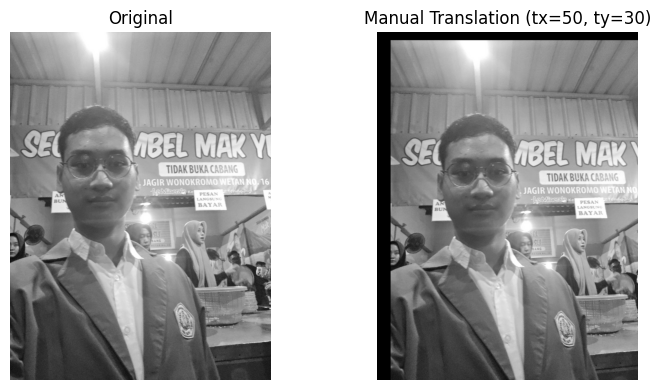

In [9]:
def manual_translation(image, tx, ty):
    """
    Fungsi translasi spasial citra manual berbasis Backward Mapping:
    x_orig = x' - tx, y_orig = y' - ty
    """
    h, w = image.shape
    translated = np.zeros((h, w), dtype=image.dtype)
    
    for y_prime in range(h):
        y_orig = y_prime - ty
        for x_prime in range(w):
            x_orig = x_prime - tx
            
            # Cek apakah koordinat asal berada dalam batas citra input
            if 0 <= x_orig < w and 0 <= y_orig < h:
                translated[y_prime, x_prime] = image[y_orig, x_orig]
            else:
                translated[y_prime, x_prime] = 0
                
    return translated

# Eksekusi translasi manual
I = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
tx = 50
ty = 30

J_trans = manual_translation(I, tx, ty)
cv2.imwrite('output/8_translasi.png', J_trans)

# Visualisasi
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(J_trans, cmap='gray')
plt.title(f'Manual Translation (tx={tx}, ty={ty})')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 9. Rotasi Citra (Perputaran Terhadap Titik Pusat $(x_0, y_0)$)

### Rumus Matematis:
Rotasi citra sebesar sudut $\theta$ (derajat) berlawanan arah jarum jam terhadap titik pusat $(x_0, y_0) = (w/2, h/2)$.
Konversi sudut ke radian: $\theta_{rad} = \theta \times \frac{\pi}{180}$.

Menggunakan **Backward (Inverse) Mapping**:
$$\begin{bmatrix} x - x_0 \\ y - y_0 \end{bmatrix} = \begin{bmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} x' - x_0 \\ y' - y_0 \end{bmatrix}$$

Sehingga koordinat asal $(x, y)$ dihitung dari koordinat target $(x', y')$ sebagai:
$$x = (x' - x_0) \cos\theta_{rad} + (y' - y_0) \sin\theta_{rad} + x_0$$
$$y = -(x' - x_0) \sin\theta_{rad} + (y' - y_0) \cos\theta_{rad} + y_0$$

Nilai pixel diinterpolasi dengan *Nearest Neighbor*:
$$x_{nn} = \text{round}(x), \quad y_{nn} = \text{round}(y)$$

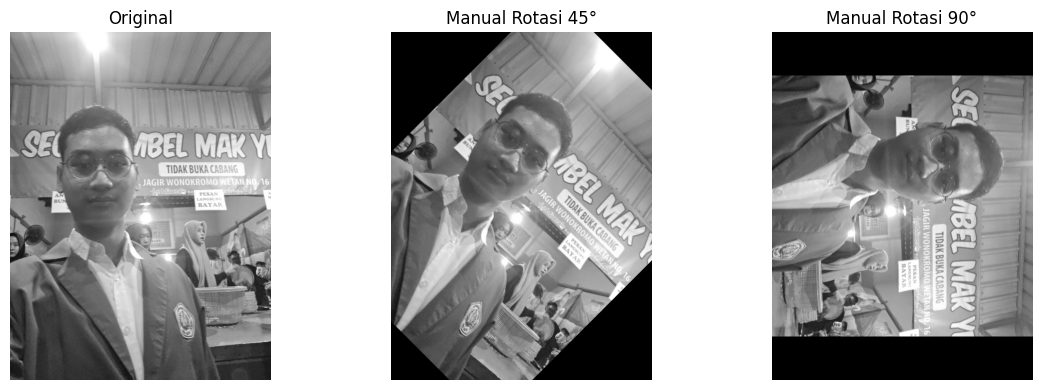

In [10]:
def manual_rotation(image, angle_deg, center=None):
    """
    Fungsi rotasi citra manual menggunakan rumus inverse mapping & Nearest Neighbor
    """
    h, w = image.shape
    if center is None:
        x0, y0 = w / 2.0, h / 2.0
    else:
        x0, y0 = center
        
    # Konversi sudut ke radian
    theta = math.radians(angle_deg)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)
    
    rotated = np.zeros((h, w), dtype=image.dtype)
    
    for y_prime in range(h):
        dy = y_prime - y0
        for x_prime in range(w):
            dx = x_prime - x0
            
            # Rumus Backward Mapping
            x_orig = round(dx * cos_t + dy * sin_t + x0)
            y_orig = round(-dx * sin_t + dy * cos_t + y0)
            
            # Periksa batasan citra (boundary check)
            if 0 <= x_orig < w and 0 <= y_orig < h:
                rotated[y_prime, x_prime] = image[int(y_orig), int(x_orig)]
            else:
                rotated[y_prime, x_prime] = 0
                
    return rotated

# Eksekusi rotasi manual
I = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
J1 = manual_rotation(I, 45)
J2 = manual_rotation(I, 90)

cv2.imwrite('output/9_rotasi_45.png', J1)
cv2.imwrite('output/9_rotasi_90.png', J2)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(I, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(J1, cmap='gray')
plt.title('Manual Rotasi 45°')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(J2, cmap='gray')
plt.title('Manual Rotasi 90°')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 10. Flipping Citra (Pencerminan Horizontal & Vertikal)

### Rumus Matematis:
- **Pencerminan Horizontal (Flip Horizontal / Sumbu Y):**
$$g(y, x) = f(y, w - 1 - x)$$

- **Pencerminan Vertikal (Flip Vertikal / Sumbu X):**
$$g(y, x) = f(h - 1 - y, x)$$

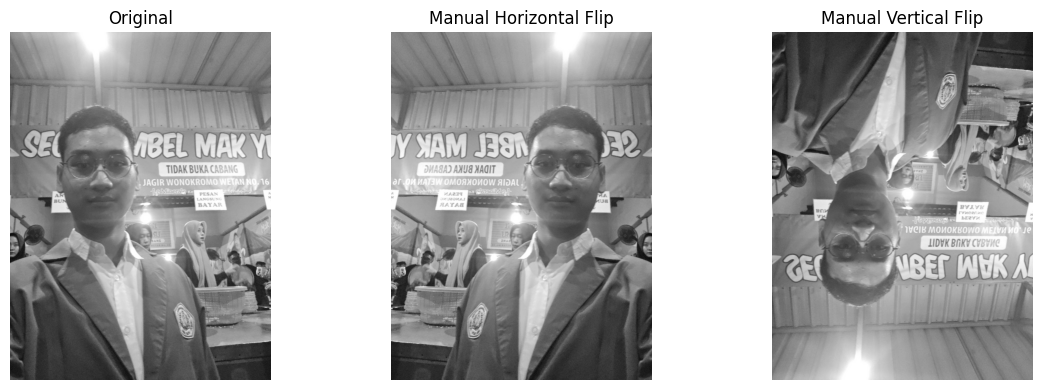

In [11]:
def manual_flip_horizontal(image):
    """
    Fungsi pencerminan horizontal manual: g(y, x) = f(y, w - 1 - x)
    """
    h, w = image.shape
    flipped = np.zeros((h, w), dtype=image.dtype)
    
    for y in range(h):
        for x in range(w):
            flipped[y, x] = image[y, w - 1 - x]
            
    return flipped

def manual_flip_vertical(image):
    """
    Fungsi pencerminan vertikal manual: g(y, x) = f(h - 1 - y, x)
    """
    h, w = image.shape
    flipped = np.zeros((h, w), dtype=image.dtype)
    
    for y in range(h):
        for x in range(w):
            flipped[y, x] = image[h - 1 - y, x]
            
    return flipped

# Eksekusi flipping manual
I = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
horizontal = manual_flip_horizontal(I)
vertical = manual_flip_vertical(I)

cv2.imwrite('output/10_flipping_horizontal.png', horizontal)
cv2.imwrite('output/10_flipping_vertical.png', vertical)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(I, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(horizontal, cmap='gray')
plt.title('Manual Horizontal Flip')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(vertical, cmap='gray')
plt.title('Manual Vertical Flip')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 11. Scaling Citra (Penskalaan Ukuran / Resizing)

### Rumus Matematis:
Penskalaan citra dengan faktor perbesaran/perkecilan spasial $s_x$ (faktor sumbu X) dan $s_y$ (faktor sumbu Y).
- Dimensi Citra Keluaran:
$$w_{out} = \text{round}(w \times s_x), \quad h_{out} = \text{round}(h \times s_y)$$

- **Backward Mapping dengan Nearest Neighbor Interpolation**:
$$x_{in} = \min\left(\max\left(\text{round}\left(\frac{x'}{s_x}\right), 0\right), w - 1\right)$$
$$y_{in} = \min\left(\max\left(\text{round}\left(\frac{y'}{s_y}\right), 0\right), h - 1\right)$$
$$g(y', x') = f(y_{in}, x_{in})$$

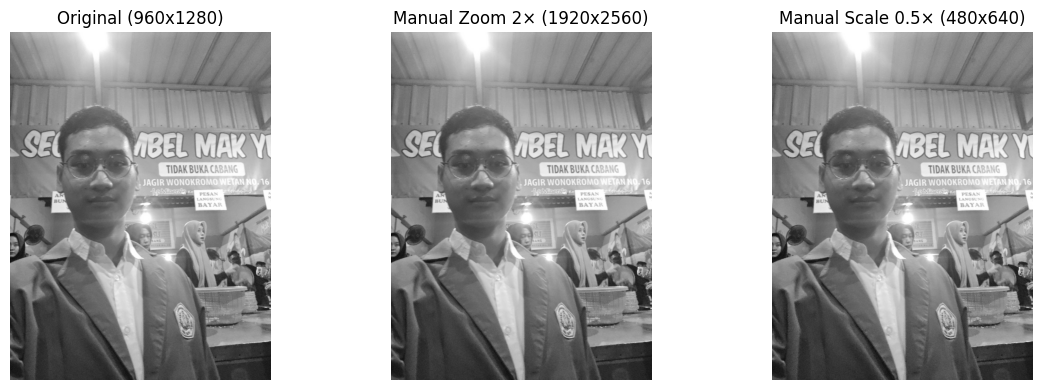

In [12]:
def manual_scaling(image, fx, fy):
    """
    Fungsi penskalaan citra manual berbasis Nearest Neighbor
    """
    h, w = image.shape
    new_h = int(round(h * fy))
    new_w = int(round(w * fx))
    
    scaled = np.zeros((new_h, new_w), dtype=image.dtype)
    
    for y_prime in range(new_h):
        y_orig = min(max(int(round(y_prime / fy)), 0), h - 1)
        for x_prime in range(new_w):
            x_orig = min(max(int(round(x_prime / fx)), 0), w - 1)
            scaled[y_prime, x_prime] = image[y_orig, x_orig]
            
    return scaled

# Eksekusi scaling manual
I = cv2.imread('input/selfie.jpg', cv2.IMREAD_GRAYSCALE)
besar = manual_scaling(I, fx=2.0, fy=2.0)
kecil = manual_scaling(I, fx=0.5, fy=0.5)

cv2.imwrite('output/11_scaling_2x.png', besar)
cv2.imwrite('output/11_scaling_0.5x.png', kecil)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(I, cmap='gray')
plt.title(f'Original ({I.shape[1]}x{I.shape[0]})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(besar, cmap='gray')
plt.title(f'Manual Zoom 2× ({besar.shape[1]}x{besar.shape[0]})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(kecil, cmap='gray')
plt.title(f'Manual Scale 0.5× ({kecil.shape[1]}x{kecil.shape[0]})')
plt.axis('off')
plt.tight_layout()
plt.show()